# CNMFe Tutorial (clean rewrite)

End-to-end walkthrough of the CNMFe pipeline on synthetic 1-photon calcium imaging data — every step explained alongside a comparison to ground truth.

**Outline**
1. Why CNMFe — the 1-photon background problem
2. Lazy zarr-native I/O
3. Motion correction
4. CORR / PNR summary images
5. Ring-model background
6. Greedy initialization
7. Spatial / temporal refinement (OASIS deconvolution)
8. Full pipeline + result inspection
9. **Trace flavours**: `C` (OASIS-deconvolved), `C + YrA` (noisy projection), and how each compares against the raw pixel trace and ground truth
10. Parallelism — `n_jobs` and `device='cuda'`

In [1]:
import sys, os, tempfile
sys.path.insert(0, '..')

import numpy as np
import scipy.ndimage as ndi
import scipy.sparse as sp
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## 1. Why CNMFe?

In **2-photon** microscopy the laser excites only a thin focal plane: every pixel records signal from one or two neurons at most, and background fluorescence is small.

In **1-photon** miniscope microscopy the entire tissue depth fluoresces. Every pixel records:
- the in-focus neurons it sits on, plus
- a large diffuse background from out-of-focus neuropil and scattering — spatially smooth, temporally drift-correlated, often larger in amplitude than individual transients.

Standard CNMF treats pixels independently and fits the structured background with spurious neural components. **CNMFe** adds a **ring-model background** (predict each pixel from a ring of neighbours) so the background is removed before running NMF on the residual.

Below we generate a synthetic 1p movie with known ground truth so we can verify every step.

In [2]:
from tests.conftest import make_synthetic_movie

data = make_synthetic_movie(n_neurons=10, dims=(64, 64), T=300,
                            noise_std=0.5, ar_decay=0.9, bg_strength=2.0, seed=161)

movie    = data['movie']     # (T, H, W) — what we observe
A_true   = data['A_true']    # (H*W, K)  — true spatial footprints
C_true   = data['C_true']    # (K, T)    — true calcium traces
S_true   = data['S_true']    # (K, T)    — true spike trains
centers  = data['centers']   # (K, 2)    — true neuron centres (row, col)
T, H, W  = movie.shape
K        = C_true.shape[0]

print(f'Movie shape:        {movie.shape}')
print(f'True neurons:       {K}')
print(f'True noise std:     {data["sn_true"]}')
print(f'True AR(1) decay g: {data["ar_decay"]}')

Movie shape:        (300, 64, 64)
True neurons:       10
True noise std:     0.5
True AR(1) decay g: 0.9


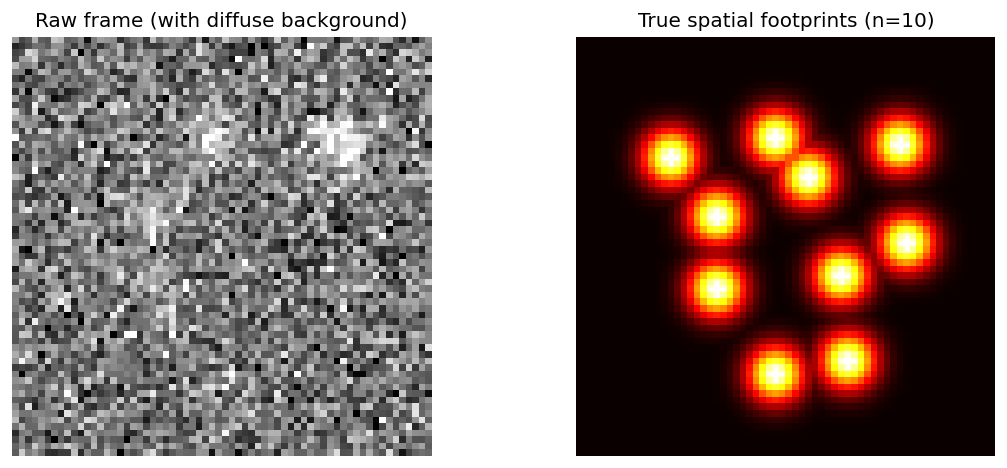

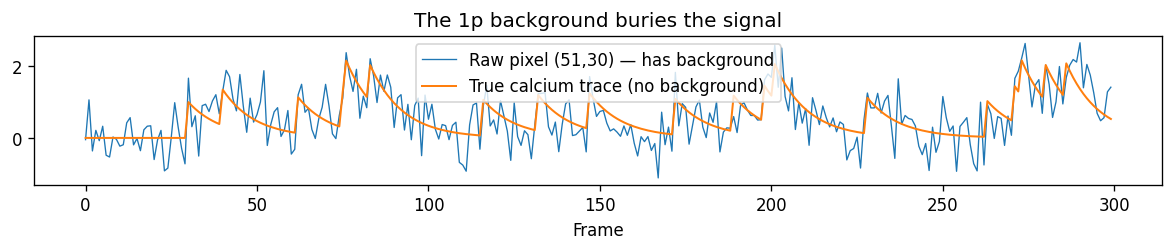

In [3]:
# --- A raw frame, the true footprints, and a raw pixel trace ---------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(movie[100], cmap='gray',
               vmin=np.percentile(movie, 1), vmax=np.percentile(movie, 99))
axes[0].set_title('Raw frame (with diffuse background)'); axes[0].axis('off')

axes[1].imshow(A_true.max(axis=1).reshape(H, W), cmap='hot')
for r, c in centers:
    axes[1].plot(c, r, 'w+', ms=10, mew=2)
axes[1].set_title(f'True spatial footprints (n={K})'); axes[1].axis('off')
plt.tight_layout(); plt.show()

# A raw pixel trace at one neuron's centre vs the underlying calcium trace
r0, c0 = centers[0]
raw_trace = movie[:, r0, c0]
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.plot(raw_trace, lw=0.8, label=f'Raw pixel ({r0},{c0}) — has background')
ax.plot(C_true[0], lw=1.2, label='True calcium trace (no background)')
ax.set_xlabel('Frame'); ax.legend()
ax.set_title('The 1p background buries the signal')
plt.tight_layout(); plt.show()

---
## 2. Lazy zarr-native I/O

A 30-minute miniscope recording at 20 fps / 256×256 px is ~6 GB — too much to load into RAM. Instead we stream into **zarr**: time-chunked, random-access, lazy.

In [4]:
from cnmfe.io import save_zarr

tmpdir = tempfile.mkdtemp()
zarr_path = os.path.join(tmpdir, 'movie.zarr')
z = save_zarr(movie, zarr_path, chunk_t=100)
print(f'zarr shape  : {z.shape}')
print(f'zarr chunks : {z.chunks}    (only the chunk containing the requested frame is read)')
print(f'zarr dtype  : {z.dtype}')

frame_50 = z[50]
print(f'Single frame access: shape={frame_50.shape}  (no full movie loaded)')

zarr shape  : (300, 64, 64)
zarr chunks : (100, 64, 64)    (only the chunk containing the requested frame is read)
zarr dtype  : float32
Single frame access: shape=(64, 64)  (no full movie loaded)


---
## 3. Motion correction

Miniscopes ride on a freely-moving animal; the brain wiggles relative to the lens. Without correction, a neuron's signal smears across pixels.

1. Pick a template (mean of first N frames).
2. For each frame, compute the cross-power spectrum with the template via FFT.
3. The peak of the inverse FFT gives the integer-pixel shift.
4. Refine to subpixel via an upsampled DFT (`skimage.registration.phase_cross_correlation`).
5. Apply the shift as a Fourier-domain phase ramp — exact, no spatial interpolation.

True drift          : [ 3.7 -2.1]
Detected correction : [-3.7  2.1]   (should equal -true_drift)
Subpixel error      : 0.000 px


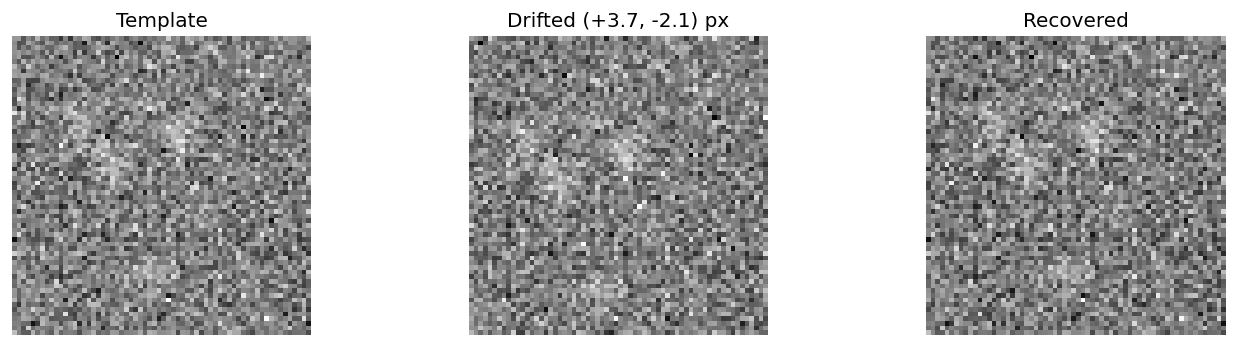

In [5]:
from cnmfe.motion_correction import estimate_shifts, apply_shift, motion_correct

# Single-frame demo: apply a known shift, then recover it.
frame = movie[50].copy()
true_drift = np.array([3.7, -2.1], dtype=np.float32)
drifted = apply_shift(frame, true_drift)
correction = estimate_shifts(drifted, frame, upsample_factor=20)

print(f'True drift          : {true_drift}')
print(f'Detected correction : {correction}   (should equal -true_drift)')
print(f'Subpixel error      : {np.abs(correction + true_drift).max():.3f} px')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(frame, cmap='gray');    axes[0].set_title('Template'); axes[0].axis('off')
axes[1].imshow(drifted, cmap='gray');  axes[1].set_title(f'Drifted ({true_drift[0]:+.1f}, {true_drift[1]:+.1f}) px'); axes[1].axis('off')
axes[2].imshow(apply_shift(drifted, correction), cmap='gray')
axes[2].set_title('Recovered'); axes[2].axis('off')
plt.tight_layout(); plt.show()

Motion correction pass 1/1:   0%|          | 0/3 [00:00<?, ?it/s]

Motion correction pass 1/1:  33%|███▎      | 1/3 [00:00<00:00,  9.15it/s]

Motion correction pass 1/1:  67%|██████▋   | 2/3 [00:00<00:00,  8.40it/s]

Motion correction pass 1/1: 100%|██████████| 3/3 [00:00<00:00,  8.65it/s]

Motion correction pass 1/1: 100%|██████████| 3/3 [00:00<00:00,  8.63it/s]

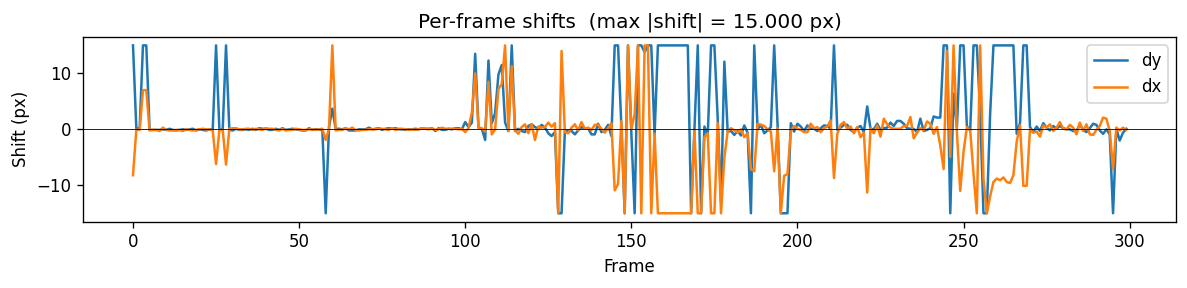

In [6]:
# Full-movie motion correction. Our synthetic movie has no motion, so shifts ~ 0.
mc_movie, shifts = motion_correct(movie, upsample_factor=10, max_shift=(15, 15), n_iter=1)
mc_movie = np.asarray(mc_movie, dtype=np.float32)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(shifts[:, 0], label='dy'); ax.plot(shifts[:, 1], label='dx')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Frame'); ax.set_ylabel('Shift (px)')
ax.set_title(f'Per-frame shifts  (max |shift| = {np.abs(shifts).max():.3f} px)')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4. CORR and PNR summary images

We need to know **where** the neurons are before we can extract them. Two complementary statistics:

- **CORR**: at each pixel, the mean Pearson correlation with its 8 neighbours over time. Neurons span several pixels that flash together → high CORR.
- **PNR**: peak-to-noise ratio — the maximum fluorescence deviation divided by the noise std. Neurons produce flashes much larger than baseline noise → high PNR.

Multiplying `CORR × PNR` gives a clean seed-score map: noisy pixels with high apparent correlation by chance get masked because their PNR is low; bright artefacts with high PNR get masked because their CORR is low.

A **center-surround** spatial filter (DoG-like, sums to zero) is applied before computing CORR/PNR to suppress the diffuse background while preserving signals at the neuron scale.

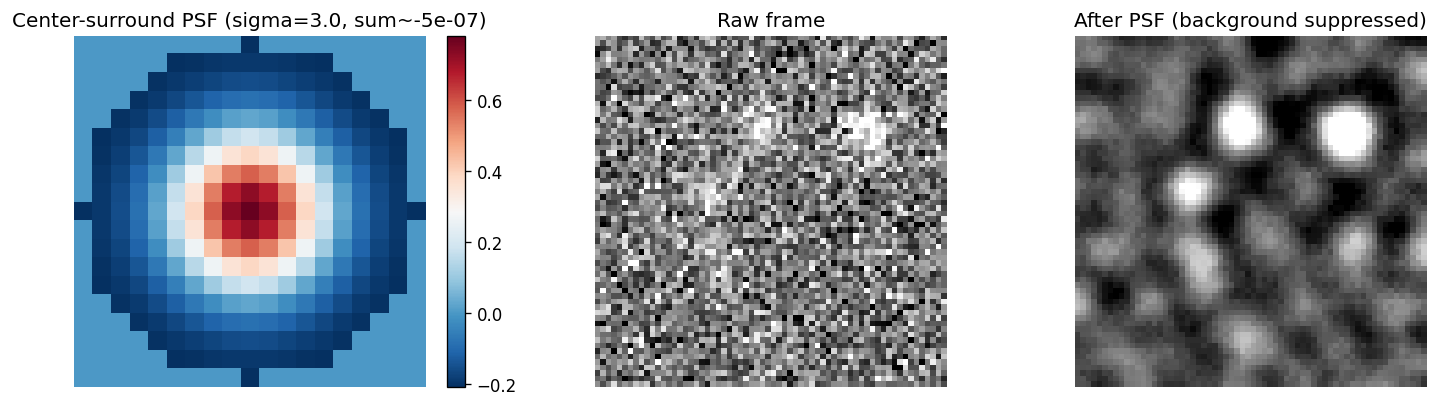

In [7]:
from cnmfe.preprocess import make_center_surround_psf, correlation_pnr, estimate_noise

sigma = 3.0
psf = make_center_surround_psf(sigma)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
im0 = axes[0].imshow(psf, cmap='RdBu_r'); plt.colorbar(im0, ax=axes[0])
axes[0].set_title(f'Center-surround PSF (sigma={sigma}, sum~{psf.sum():.0e})')

raw_frame = mc_movie[100]
filtered = ndi.convolve(raw_frame, psf, mode='reflect')
vmin, vmax = np.percentile(raw_frame, [2, 98])
axes[1].imshow(raw_frame, cmap='gray', vmin=vmin, vmax=vmax); axes[1].set_title('Raw frame')
fmin, fmax = np.percentile(filtered, [2, 98])
axes[2].imshow(filtered, cmap='gray', vmin=fmin, vmax=fmax); axes[2].set_title('After PSF (background suppressed)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

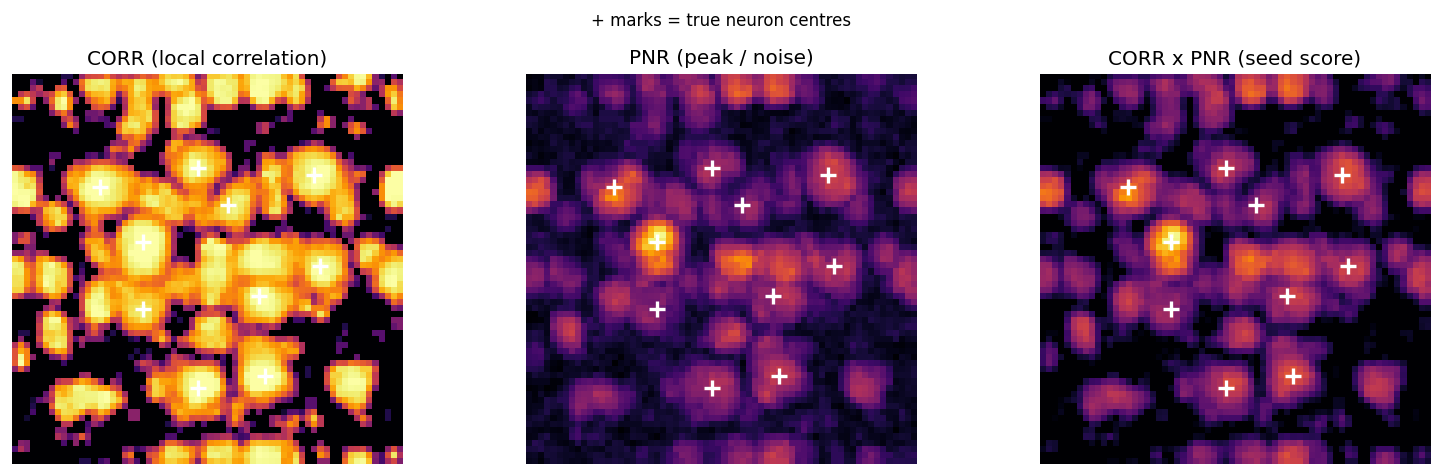

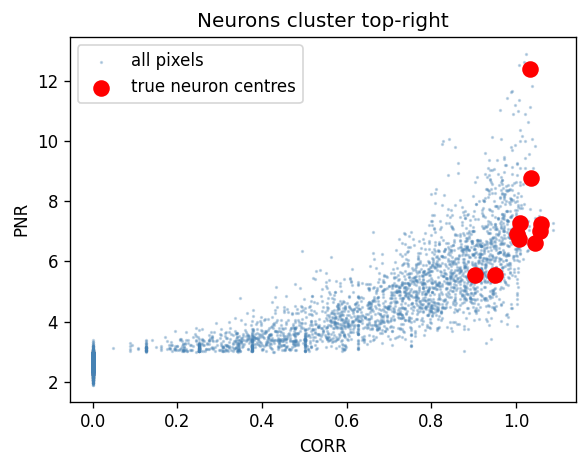

In [8]:
# Compute CORR and PNR images on the (PSF-filtered) movie
cn, pnr = correlation_pnr(mc_movie, sigma=sigma, center_psf=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(cn, cmap='inferno', vmin=0, vmax=1)
axes[1].imshow(pnr, cmap='inferno')
axes[2].imshow(cn * pnr, cmap='inferno')
for ax, title in zip(axes, ['CORR (local correlation)', 'PNR (peak / noise)', 'CORR x PNR (seed score)']):
    for r, c in centers:
        ax.plot(c, r, 'w+', ms=10, mew=2)
    ax.set_title(title); ax.axis('off')
plt.suptitle('+ marks = true neuron centres', fontsize=10)
plt.tight_layout(); plt.show()

# Scatter — neurons cluster in the high-CORR / high-PNR region
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(cn.ravel(), pnr.ravel(), s=1, alpha=0.3, c='steelblue', label='all pixels')
ax.scatter(cn[centers[:, 0], centers[:, 1]], pnr[centers[:, 0], centers[:, 1]],
           s=80, c='red', zorder=5, label='true neuron centres')
ax.set_xlabel('CORR'); ax.set_ylabel('PNR'); ax.legend()
ax.set_title('Neurons cluster top-right')
plt.tight_layout(); plt.show()

---
## 5. Ring-model background

> The background at any pixel is well approximated by a weighted sum of pixels in a **ring** around it (radius slightly larger than a neuron), because the background is spatially smooth on scales > 1 neuron.

For each pixel $i$:

$$\min_{w_i}\;\|X_i - w_i^\top X_{\mathcal{R}_i}\|^2 + \lambda \|w_i\|^2,\quad X = Y - AC$$

Closed-form ridge regression. The result is a sparse $(H\!\cdot\!W)\times(H\!\cdot\!W)$ weight matrix `W`, plus a per-pixel baseline `b0`. Background-subtracted data:

$$Y_{\text{bg}} = Y - b_0 - W(Y - b_0)$$

Ring radius: 10.5 px


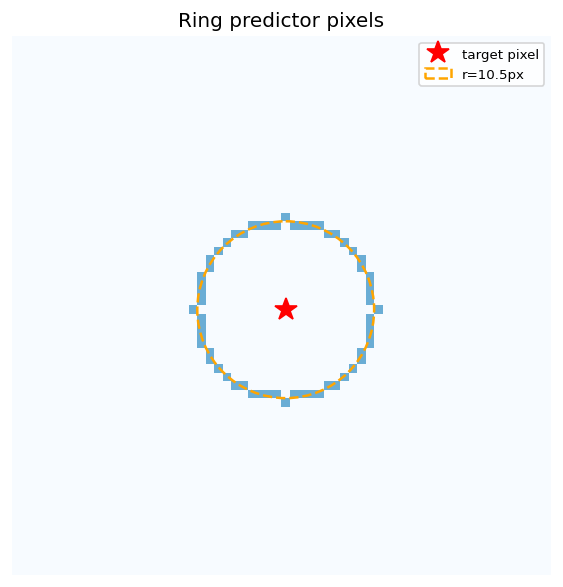

In [9]:
from cnmfe.background import build_ring_indices, compute_W, subtract_background
from cnmfe._utils import make_2d

ring_radius = 1.5 * (2 * sigma + 1)
print(f'Ring radius: {ring_radius:.1f} px')

# Visualise the ring of one pixel
rings = build_ring_indices((H, W), ring_radius)
centre_pixel = (H // 2) * W + (W // 2)
ring_mask = np.zeros(H * W, dtype=bool)
ring_mask[rings[centre_pixel]] = True

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(ring_mask.reshape(H, W).astype(float), cmap='Blues', vmin=0, vmax=2)
ax.plot(W // 2, H // 2, 'r*', ms=14, label='target pixel')
ax.add_patch(plt.Circle((W // 2, H // 2), ring_radius, fill=False,
             color='orange', lw=1.5, ls='--', label=f'r={ring_radius:.1f}px'))
ax.legend(fontsize=8); ax.set_title('Ring predictor pixels'); ax.axis('off')
plt.tight_layout(); plt.show()

W shape: (4096, 4096),  nnz: 196856  (48.1 non-zeros per row)


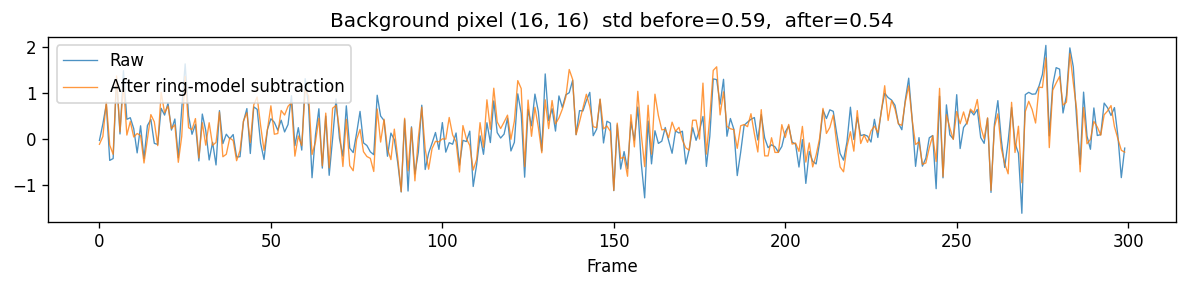

In [10]:
# Demo: fit W using the TRUE A and C (so we isolate the background fitting itself)
A_sp = sp.csc_matrix(A_true.astype(np.float32))
Y_flat = make_2d(mc_movie)
W_mat, b0 = compute_W(Y_flat, A_sp, C_true, (H, W), ring_radius, lambda_reg=1e-5)
print(f'W shape: {W_mat.shape},  nnz: {W_mat.nnz}  ({W_mat.nnz / W_mat.shape[0]:.1f} non-zeros per row)')

Y_bg = subtract_background(Y_flat, W_mat, b0)

# A pixel away from any neuron — the ring model should reduce its variance dramatically
bg_row, bg_col = H // 4, W // 4
px_idx = bg_row * W + bg_col
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(Y_flat[px_idx], lw=0.8, alpha=0.8, label='Raw')
ax.plot(Y_bg[px_idx],  lw=0.8, alpha=0.8, label='After ring-model subtraction')
ax.set_xlabel('Frame'); ax.legend()
ax.set_title(f'Background pixel ({bg_row}, {bg_col})  '
             f'std before={Y_flat[px_idx].std():.2f},  after={Y_bg[px_idx].std():.2f}')
plt.tight_layout(); plt.show()

---
## 6. Greedy initialization

Find neurons one at a time, brightest first:

1. Pick the pixel with the highest `CORR × PNR`.
2. Extract the neuron's footprint and trace from a small patch around it (3-component OLS: trace, local background, baseline).
3. Deconvolve the trace with OASIS (clean AR(1) shape).
4. Subtract `a_i * c_i` from the data.
5. Recompute `CORR × PNR` locally; suppress a disk of radius `~2σ` around every found centre so the residual halo of one neuron can't seed the next.
6. Repeat until no pixel passes the threshold.

Greedy works well because we always remove the strongest neuron first — easy cases never interfere with hard ones.

Seeds found: 24  (top 5 by score)
  ( 26,  21)  score = 13.20
  ( 20,  14)  score = 10.45
  ( 30,  34)  score = 9.56
  (  3,  34)  score = 8.98
  ( 31,  41)  score = 8.29


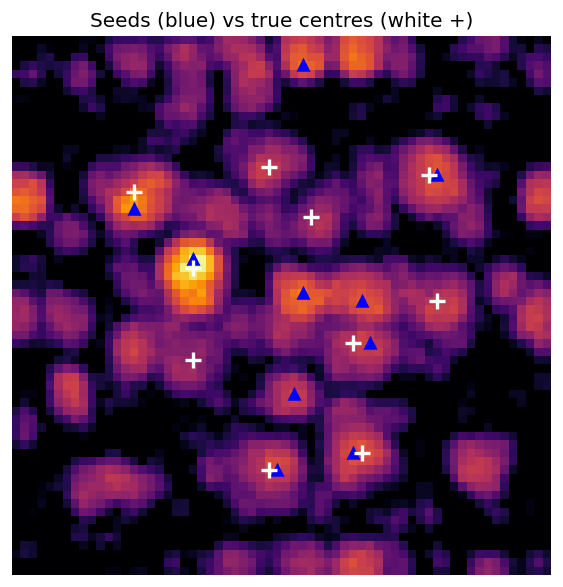

In [11]:
from cnmfe.initialization import detect_seeds, greedy_corr_pnr

seeds = detect_seeds(cn, pnr, min_corr=0.7, min_pnr=4.0, min_distance=int(sigma))
print(f'Seeds found: {len(seeds)}  (top 5 by score)')
for row, col in seeds[:5]:
    print(f'  ({row:3d}, {col:3d})  score = {cn[row,col]*pnr[row,col]:.2f}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cn * pnr, cmap='inferno')
for r, c in seeds[:10]: ax.plot(c, r, 'b^', ms=6, mew=1.5)
for r, c in centers:     ax.plot(c, r, 'w+', ms=10, mew=2)
ax.set_title('Seeds (blue) vs true centres (white +)'); ax.axis('off')
plt.tight_layout(); plt.show()

Initialized 20 components (truth = 10)


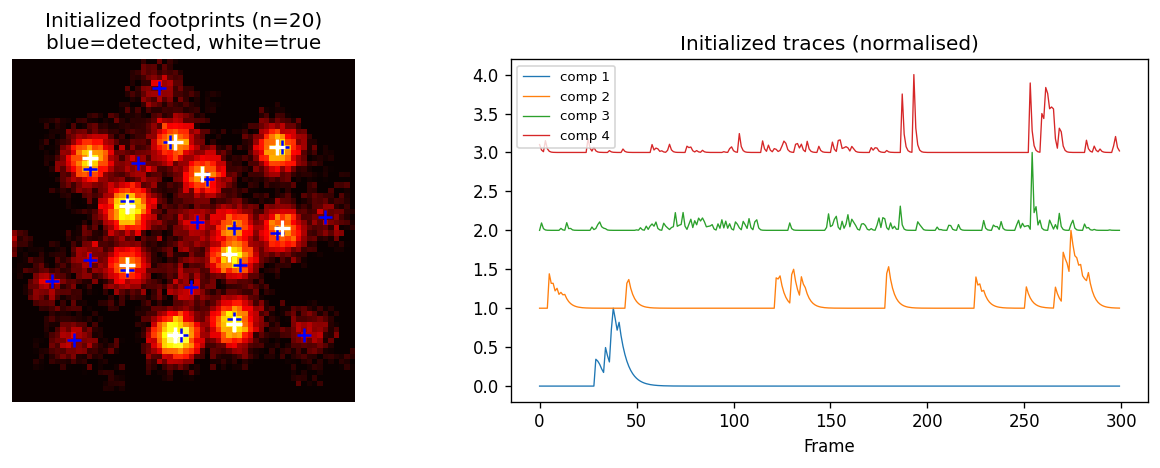

In [12]:
A_init, C_init, C_raw_init, centers_init = greedy_corr_pnr(
    mc_movie, sigma=sigma, min_corr=0.8, min_pnr=6.0, ar_order=1, border_px=5
)
K_init = A_init.shape[1]
print(f'Initialized {K_init} components (truth = {K})')

A_init_dense = np.asarray(A_init.todense()).reshape(H, W, K_init)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(A_init_dense.max(axis=2), cmap='hot')
for r, c in centers_init: axes[0].plot(c, r, 'b+', ms=8, mew=1.5)
for r, c in centers:        axes[0].plot(c, r, 'w+', ms=10, mew=2)
axes[0].set_title(f'Initialized footprints (n={K_init})\nblue=detected, white=true')
axes[0].axis('off')

for k in range(min(4, K_init)):
    axes[1].plot(C_init[k] / (C_init[k].max() + 1e-10) + k, lw=0.8, label=f'comp {k+1}')
axes[1].set_xlabel('Frame'); axes[1].set_title('Initialized traces (normalised)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 7. Spatial / temporal refinement

The initialization is approximate. We refine in alternating passes:

### Spatial update
For each pixel $p$, solve a small non-negative LASSO:

$$a_p = \arg\min_{a \geq 0}\;\|Y_p - C[\mathcal{A}_p]^\top a\|^2 + \lambda \|a\|_1$$

where $\mathcal{A}_p$ is the set of components whose dilated footprint covers pixel $p$.

### Temporal update (block coordinate descent)
For each component $k$, project the residual onto $a_k$ and deconvolve with OASIS:

$$\text{trace}_k = \frac{a_k^\top Y - \sum_{j\neq k}(a_k^\top a_j) c_j}{\|a_k\|^2}\quad\text{then OASIS}\to (c_k, s_k)$$

### AR(1) coefficient
The decay constant $g$ is estimated **once** per pipeline run from the pooled raw traces and reused for every BCD pass. Re-estimating from already-deconvolved traces would re-apply the noise-correction factor and drift $g$ toward 0.

### Merging
Two components that are temporally correlated AND either spatially overlapping OR centred close together (within a couple of σ) are merged.

Estimated g = 0.791   (true g = 0.900)
Estimated sn = 0.021


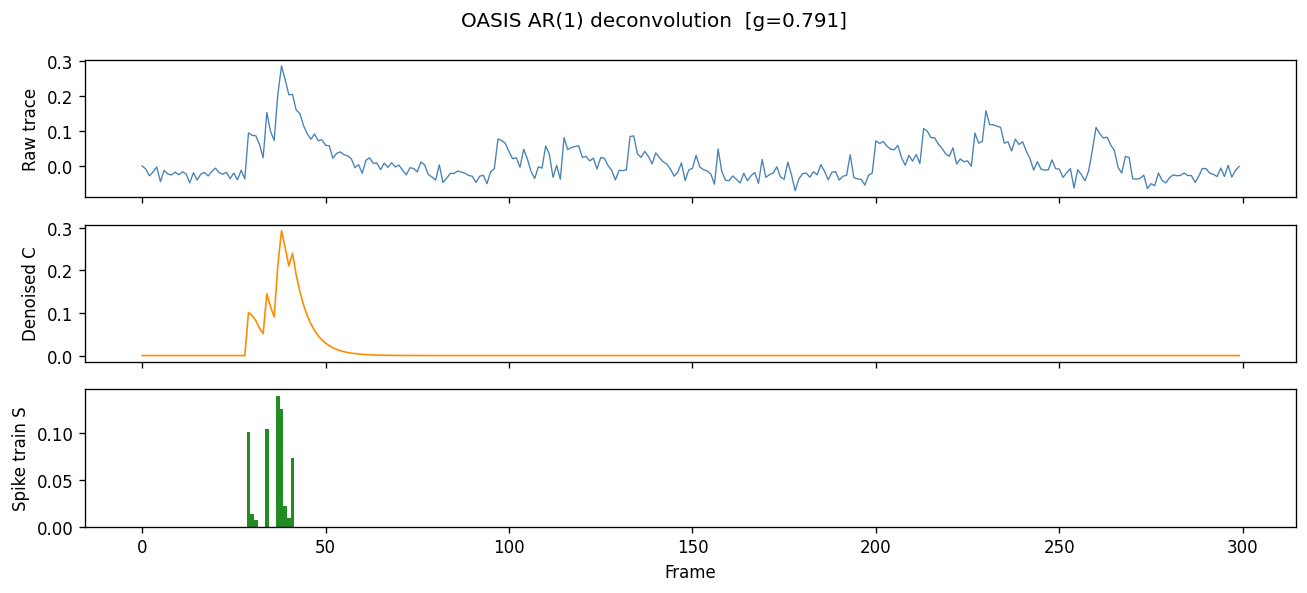

In [13]:
from cnmfe.temporal import estimate_ar_params, deconvolve

trace_raw = C_raw_init[0]
g, sn = estimate_ar_params(trace_raw, p=1)
c_clean, s_train, baseline = deconvolve(trace_raw, g, sn)

print(f'Estimated g = {g[0]:.3f}   (true g = {data["ar_decay"]:.3f})')
print(f'Estimated sn = {sn:.3f}')

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)
axes[0].plot(trace_raw, lw=0.8, color='steelblue'); axes[0].set_ylabel('Raw trace')
axes[1].plot(c_clean,  lw=1.0, color='darkorange'); axes[1].set_ylabel('Denoised C')
axes[2].bar(np.arange(len(s_train)), s_train, width=1, color='forestgreen', linewidth=0)
axes[2].set_ylabel('Spike train S'); axes[2].set_xlabel('Frame')
plt.suptitle(f'OASIS AR(1) deconvolution  [g={g[0]:.3f}]')
plt.tight_layout(); plt.show()

---
## 8. Full pipeline

`CNMFe.fit()` stitches everything together. Tuned for the synthetic movie above; for real data set `sigma` to the observed neuron radius and pick `min_corr` / `min_pnr` from the CORR × PNR scatter.

In [14]:
from cnmfe.pipeline import CNMFe, CNMFeParams
from tests.test_pipeline import match_components

params = CNMFeParams(
    sigma=3.0,
    min_corr=0.8,
    min_pnr=6.0,
    n_iter_main=2,
    n_iter_temporal=2,
    mc_n_iter=1,
    spatial_max_thr=0.1,
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
)

model = CNMFe(params).fit(movie, do_motion_correction=False)

print(f'\nExtracted {model.A.shape[1]} neurons (truth = {K})')
print(f'A   shape: {model.A.shape}   - sparse spatial footprints')
print(f'C   shape: {model.C.shape}      - OASIS-deconvolved (clean AR(1))')
print(f'YrA shape: {model.YrA.shape}      - residual; C + YrA is the noisy projection')
print(f'S   shape: {model.S.shape}      - spike trains')
print(f'g   list:  len={len(model.g)}   first AR coef = {model.g[0][0]:.3f}')

Estimating noise...
Computing CORR and PNR images...


Running greedy CORR-PNR initialization...


  Found 10 initial components.
Fitting ring-model background (radius=10.5px)...


Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  Updating spatial footprints...


  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).


Refinement iteration 2/2...
  Updating spatial footprints...


  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).


Final temporal update...
Done. Extracted 10 neurons.

Extracted 10 neurons (truth = 10)
A   shape: (4096, 10)   - sparse spatial footprints
C   shape: (10, 300)      - OASIS-deconvolved (clean AR(1))
YrA shape: (10, 300)      - residual; C + YrA is the noisy projection
S   shape: (10, 300)      - spike trains
g   list:  len=10   first AR coef = 0.806


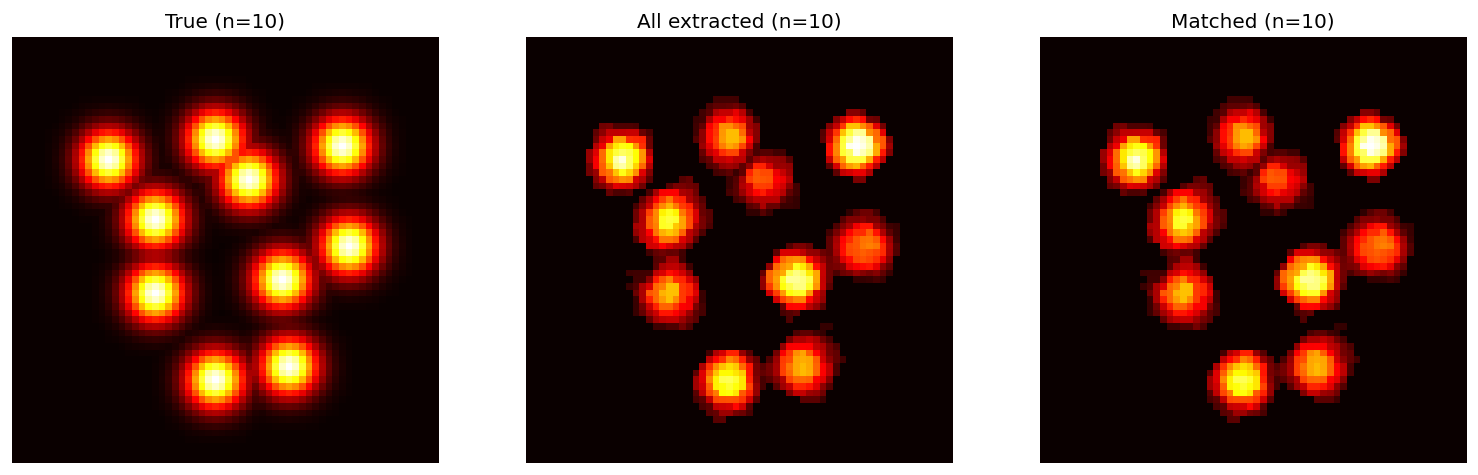

Recovered 10/10 true neurons (spatial r > 0.5)
Spatial correlation per true neuron:
  true  0  <->  extracted  8    r = 0.971
  true  1  <->  extracted  4    r = 0.970
  true  2  <->  extracted  0    r = 0.980
  true  3  <->  extracted  6    r = 0.951
  true  4  <->  extracted  5    r = 0.963
  true  5  <->  extracted  7    r = 0.977
  true  6  <->  extracted  1    r = 0.967
  true  7  <->  extracted  2    r = 0.974
  true  8  <->  extracted  9    r = 0.973
  true  9  <->  extracted  3    r = 0.971


In [15]:
# --- Spatial overlay: truth | all extracted | matched-only -----------------
K_found = model.A.shape[1]
A_dense = np.asarray(model.A.todense()).reshape(H, W, K_found)
matches = match_components(model.A, A_true)
matched_idxs = sorted({k_est for _, k_est, c in matches if c > 0.5})

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(A_true.max(axis=1).reshape(H, W), cmap='hot')
axes[0].set_title(f'True (n={K})'); axes[0].axis('off')
axes[1].imshow(A_dense.max(axis=2), cmap='hot')
axes[1].set_title(f'All extracted (n={K_found})'); axes[1].axis('off')
matched_overlay = A_dense[:, :, matched_idxs].max(axis=2) if matched_idxs else np.zeros((H, W))
axes[2].imshow(matched_overlay, cmap='hot')
axes[2].set_title(f'Matched (n={len(matched_idxs)})'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f'Recovered {len(matched_idxs)}/{K} true neurons (spatial r > 0.5)')
print('Spatial correlation per true neuron:')
for k_true, k_est, corr in sorted(matches):
    print(f'  true {k_true:2d}  <->  extracted {k_est:2d}    r = {corr:.3f}')

---
## 9. Two flavours of the calcium trace — and how they compare to the data

CNMFe exposes two related calcium traces for each neuron:

| Attribute | What it is | When to use |
|-----------|-----------|-------------|
| `model.C[k]` | OASIS-deconvolved trace — clean AR(1) shape | Spike-event detection, smooth amplitude features |
| `model.C[k] + model.YrA[k]` | Noisy *projected* trace — the data at that footprint with all *other* neurons subtracted | Shape-faithful comparisons: cross-correlating with a behavioural variable, regressing against an external reference, anywhere the OASIS shape constraint would distort the answer |

Below we compare both flavours against (a) ground truth and (b) the raw single-pixel trace at each neuron's centre. Same neuron, three viewpoints.

In [16]:
def pearson(a, b):
    a = a - a.mean(); b = b - b.mean()
    d = np.sqrt(np.sum(a ** 2) * np.sum(b ** 2))
    return float(np.dot(a, b) / d) if d > 0 else 0.0

def norm01(x):
    lo, hi = float(np.min(x)), float(np.max(x))
    return (x - lo) / (hi - lo + 1e-10)

C_proj = model.C + model.YrA   # (K, T) noisy projection

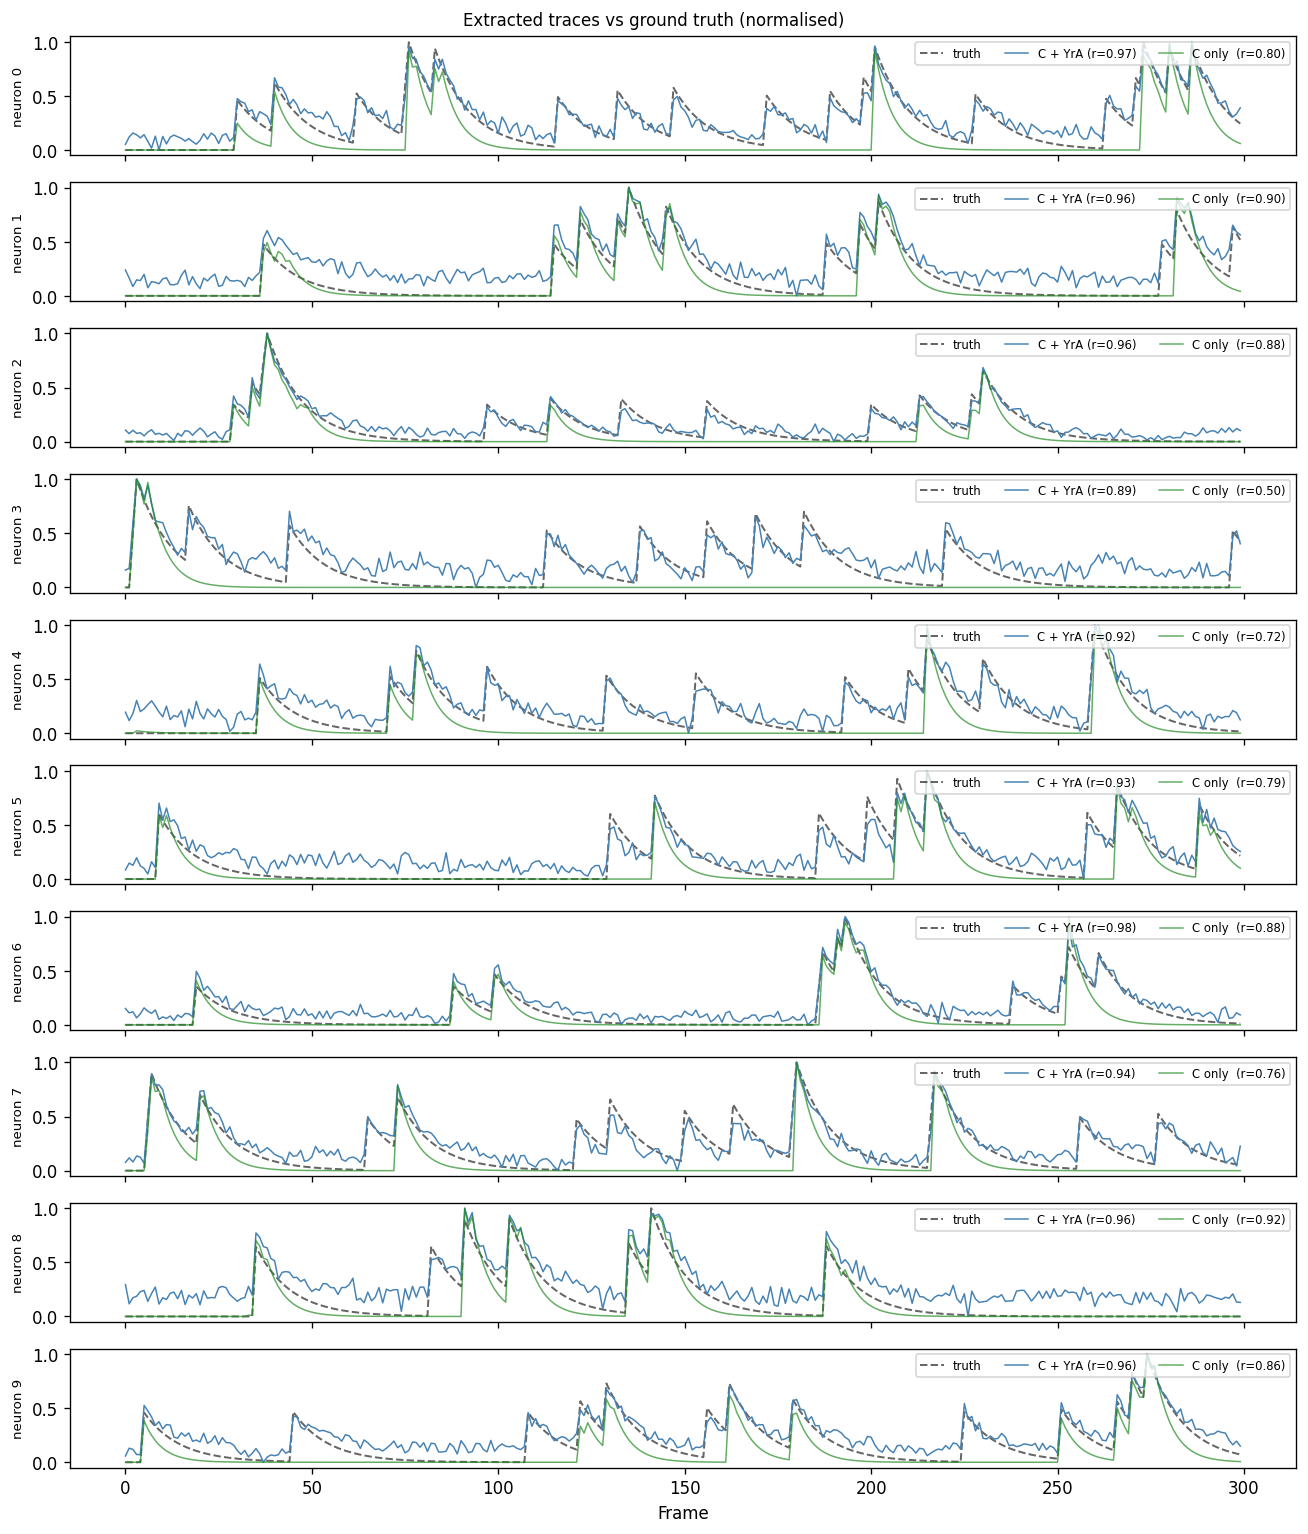

Mean Pearson r vs truth:  C only = 0.801,  C + YrA = 0.947


In [17]:
# --- (a) C and C + YrA vs ground truth -------------------------------------
n_rows = len(matches)
fig, axes = plt.subplots(n_rows, 1, figsize=(11, 1.3 * n_rows), sharex=True)
if n_rows == 1: axes = [axes]
for ax, (k_true, k_est, sc) in zip(axes, sorted(matches)):
    r_oasis = pearson(model.C[k_est], C_true[k_true])
    r_proj  = pearson(C_proj[k_est],  C_true[k_true])
    ax.plot(norm01(C_true[k_true]), lw=1.2, color='black', ls='--', alpha=0.6, label='truth')
    ax.plot(norm01(C_proj[k_est]),  lw=0.9, color='steelblue',
            label=f'C + YrA (r={r_proj:.2f})')
    ax.plot(norm01(model.C[k_est]), lw=0.9, color='forestgreen', alpha=0.7,
            label=f'C only  (r={r_oasis:.2f})')
    ax.set_ylabel(f'neuron {k_true}', fontsize=8)
    ax.legend(loc='upper right', fontsize=7, ncol=3)
axes[-1].set_xlabel('Frame')
plt.suptitle('Extracted traces vs ground truth (normalised)', fontsize=10)
plt.tight_layout(); plt.show()

rs_oasis = [pearson(model.C[ke], C_true[kt]) for kt, ke, _ in matches]
rs_proj  = [pearson(C_proj[ke],  C_true[kt]) for kt, ke, _ in matches]
print(f'Mean Pearson r vs truth:  C only = {np.mean(rs_oasis):.3f},  '
      f'C + YrA = {np.mean(rs_proj):.3f}')

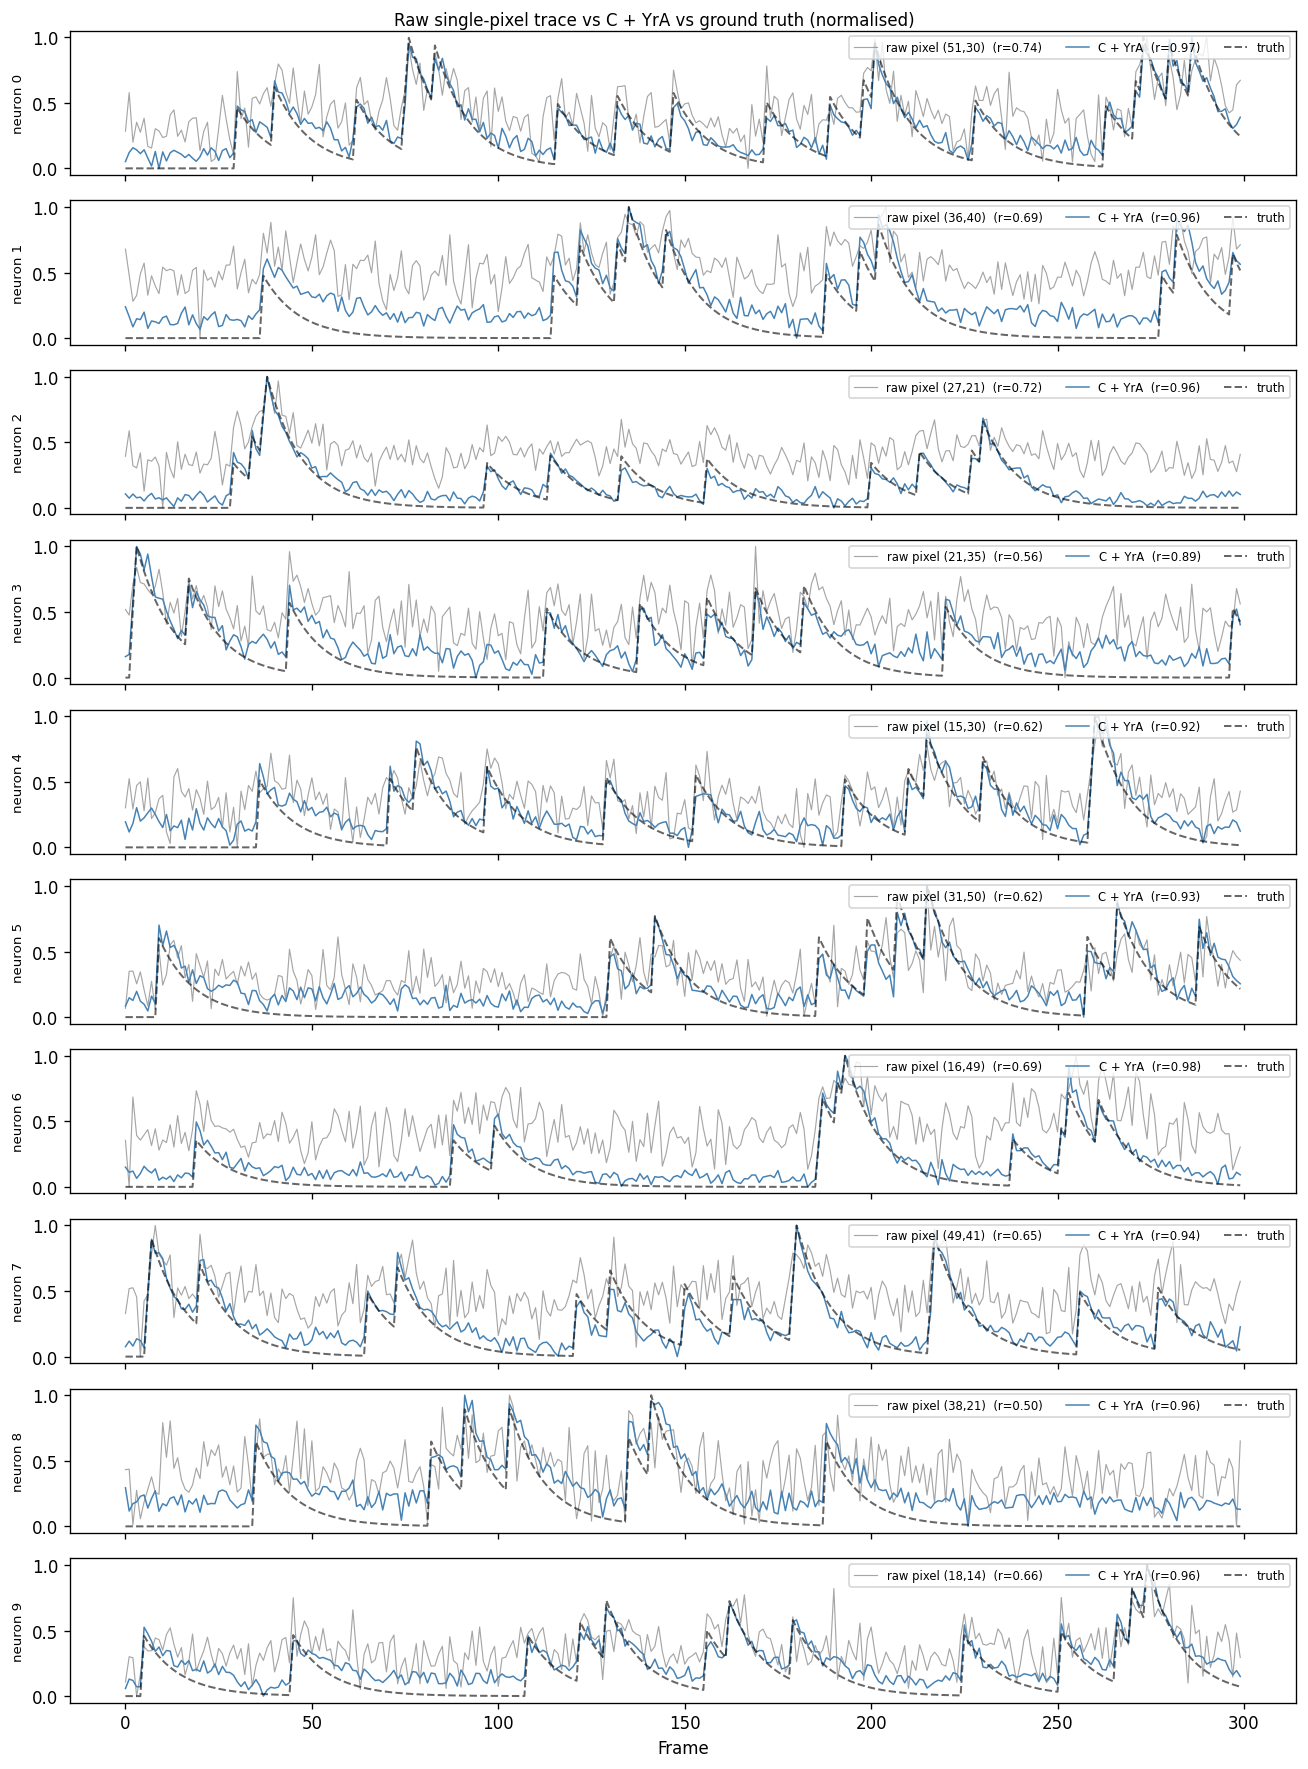

Mean Pearson r vs truth:  raw pixel = 0.647,  C + YrA = 0.947


In [18]:
# --- (b) Raw single-pixel trace (neuron centre) vs C + YrA vs truth -------
# The raw pixel at a neuron's centre still has the diffuse 1p background
# riding on top of the calcium signal — we plot it after subtracting the
# pixel's own mean so the y-scale is comparable. C + YrA recovers the calcium
# shape from the data even though every pixel is contaminated.

n_rows = len(matches)
fig, axes = plt.subplots(n_rows, 1, figsize=(11, 1.5 * n_rows), sharex=True)
if n_rows == 1: axes = [axes]
for ax, (k_true, k_est, sc) in zip(axes, sorted(matches)):
    r0, c0 = centers[k_true]
    raw_pixel = movie[:, r0, c0]
    raw_pixel = raw_pixel - raw_pixel.mean()                # remove DC for plotting

    r_raw  = pearson(raw_pixel,        C_true[k_true])
    r_proj = pearson(C_proj[k_est],    C_true[k_true])

    ax.plot(norm01(raw_pixel),        lw=0.7, color='gray',      alpha=0.7,
            label=f'raw pixel ({r0},{c0})  (r={r_raw:.2f})')
    ax.plot(norm01(C_proj[k_est]),    lw=0.9, color='steelblue',
            label=f'C + YrA  (r={r_proj:.2f})')
    ax.plot(norm01(C_true[k_true]),   lw=1.2, color='black', ls='--', alpha=0.6,
            label='truth')
    ax.set_ylabel(f'neuron {k_true}', fontsize=8)
    ax.legend(loc='upper right', fontsize=7, ncol=3)
axes[-1].set_xlabel('Frame')
plt.suptitle('Raw single-pixel trace vs C + YrA vs ground truth (normalised)', fontsize=10)
plt.tight_layout(); plt.show()

rs_raw  = [pearson(movie[:, centers[kt][0], centers[kt][1]], C_true[kt]) for kt, _, _ in matches]
rs_proj = [pearson(C_proj[ke], C_true[kt])                                for kt, ke, _ in matches]
print(f'Mean Pearson r vs truth:  raw pixel = {np.mean(rs_raw):.3f},  '
      f'C + YrA = {np.mean(rs_proj):.3f}')

---
## 10. Summary

| Step | What it does | Why |
|------|-------------|-----|
| Zarr I/O | Time-chunked random-access movie | No need to load the whole file |
| Motion correction | Rigid FFT-based alignment | Avoid smeared footprints |
| Center-surround PSF | Spatial bandpass | Suppress diffuse background |
| CORR / PNR | Where are the neurons? | Provides seeds |
| Ring background | Per-pixel ridge regression | Removes correlated 1p background |
| Greedy init | Iterative seed → extract → subtract | Robust: strongest neuron first |
| Spatial update | Per-pixel non-negative LASSO | Refine footprint boundaries |
| Temporal update + OASIS | Block CD + AR(1) deconvolution | Clean trace + spike train |
| Merging | Combine duplicate detections | Catches near-duplicates that survived init |

**Key parameters**

| Parameter | Effect | Typical |
|-----------|--------|---------|
| `sigma` | Neuron radius (px) | 2–5 |
| `min_corr` | Min CORR for a seed | 0.6–0.9 |
| `min_pnr` | Min PNR for a seed | 5–15 |
| `n_iter_main` | Refinement passes | 2–3 |
| `merge_thr_corr` | Min temporal r to merge | 0.75–0.95 |
| `merge_centre_dist_factor` | Centre-distance fallback for merging (× σ) | 1.5–2.5 |
| `spatial_max_thr` | Footprint cleanup threshold | 0.05–0.2 |

---
## 11. Parallelism

`n_jobs` controls CPU parallelism (joblib/loky); `device='cuda'` runs the parallelisable steps on GPU via CuPy.

| Step | n_jobs parallel? | GPU? |
|------|----------------|-------|
| Motion correction | yes (per-frame) | yes |
| CORR / PNR | yes (per-frame) | yes |
| Ring background | yes (per-pixel batch) | yes |
| Spatial update | yes (per-pixel batch) | no (sklearn LassoLars) |
| Temporal update | yes (Jacobi BCD) | partial (projection only) |
| Greedy loop | no (sequential) | initial PSF only |
| OASIS | no (sequential PAVA) | no |

> **Windows**: workers spawn (no fork). Always wrap script-level `fit()` calls in `if __name__ == "__main__":`.

In [19]:
import time

demo_params = dict(sigma=3.0, min_corr=0.8, min_pnr=6.0,
                   n_iter_main=2, n_iter_temporal=2, mc_n_iter=1)

t0 = time.time()
serial_model = CNMFe(CNMFeParams(**demo_params, n_jobs=1)).fit(movie, do_motion_correction=False)
t_serial = time.time() - t0

t0 = time.time()
par_model = CNMFe(CNMFeParams(**demo_params, n_jobs=4)).fit(movie, do_motion_correction=False)
t_parallel = time.time() - t0

print()
print(f'Serial   (n_jobs=1):  {t_serial:5.2f}s   neurons = {serial_model.A.shape[1]}')
print(f'Parallel (n_jobs=4):  {t_parallel:5.2f}s   neurons = {par_model.A.shape[1]}')
print(f'Speedup: {t_serial / t_parallel:4.2f}x')
print()
print('On a 64x64x300 movie the per-frame work is small, so worker startup dominates.')
print('For real recordings (>= 256x256, T >= 1000) expect 3-6x speedup with n_jobs=-1.')

Estimating noise...
Computing CORR and PNR images...


Running greedy CORR-PNR initialization...


  Found 10 initial components.
Fitting ring-model background (radius=10.5px)...


Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  Updating spatial footprints...


  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).


...

Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  Updating spatial footprints...


  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).


Refinement iteration 2/2...
  Updating spatial footprints...


  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).


Final temporal update...
Done. Extracted 10 neurons.

Serial   (n_jobs=1):   6.93s   neurons = 10
Parallel (n_jobs=4):   8.73s   neurons = 10
Speedup: 0.79x

On a 64x64x300 movie the per-frame work is small, so worker startup dominates.
For real recordings (>= 256x256, T >= 1000) expect 3-6x speedup with n_jobs=-1.
